# JUSTICE TEFERA
# Applied Analytics (EDA)

- Author: JUSTICE TEFERA
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06


## 📦 Dataset Description

The **Crime_Data.csv** file contains approximately **481,000 police‑reported crime incidents** from the **City of Seattle, WA**, spanning a period of roughly **ten years**. This dataset provides a comprehensive and detailed view of crime activity across Seattle’s neighborhoods and police jurisdictions.

Each crime report includes precise **date and time information**, enabling analysis of hourly, daily, and seasonal crime patterns. The dataset also contains multiple layers of **crime classification**, including offense category, subcategory, and descriptive labels, allowing both high‑level trend analysis and fine‑grained examination of specific crime types.

In addition to offense details, the dataset incorporates extensive **Seattle Police Department (SPD) operational geography**, including the **precinct**, **sector**, and **beat** associated with each incident. These fields reflect the organizational structure of SPD patrol areas and support spatial analysis at multiple levels of granularity.

The dataset further includes the **neighborhood name** for each incident, providing a community‑level perspective on crime distribution across Seattle. This enables the identification of persistent hotspots, neighborhood‑specific crime patterns, and potential correlations with demographic or environmental factors.

Overall, this dataset offers a rich, multi‑dimensional foundation for analyzing crime trends in Seattle, supporting both exploratory data analysis and more advanced modeling of spatial, temporal, and behavioral patterns.

**Data Source:**  
Crime dataset obtained from Kaggle: *Crime Dataset Analysis* by theyazilimci  
https://www.kaggle.com/code/theyazilimci/crime-dataset-analysis/input


## Section 1. Project Setup and Imports



In [109]:
import os

if "notebooks" in os.getcwd():
    os.makedirs("figures", exist_ok=True)
    os.chdir("..")

In [110]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging
import os
from typing import Any, Final

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("JT-NB", level="DEBUG")
log_header(LOG, "JT-NB")

# === Section 1c. Global Constants and Configuration ===
# These constants are SPECIFIC to your Crime_Data.csv dataset.

DATASET_NAME: Final[str] = "Crime_Data.csv"

# Grouping column (categorical)
GROUP_COL: Final[str] = "Crime Subcategory"

# Numeric columns to analyze (your engineered numeric features)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "Occurred Hour",
    "Reported Hour",
    "Occurred Month",
    "Occurred Year",
    "Report Delay (Hours)",
]

# One numeric column for manual statistics
EXAMPLE_NUMERIC_COL: Final[str] = "Occurred Hour"

# Scatterplot variables
SCATTER_X_COL: Final[str] = "Occurred Hour"
SCATTER_Y_COL: Final[str] = "Report Delay (Hours)"

# Boxplot variable
BOX_Y_COL: Final[str] = "Occurred Hour"

# Readable labels for charts
SCATTER_X_LABEL: Final[str] = "Hour of Occurrence"
SCATTER_Y_LABEL: Final[str] = "Reporting Delay (Hours)"
BOX_Y_LABEL: Final[str] = "Hour of Occurrence"

# === Section 1d. Pandas Configuration for Display ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports and configuration complete.")

2026-06-19 10:59:34 | INFO | JT-NB | === RUN START ===
2026-06-19 10:59:34 | INFO | JT-NB | project=JT-NB
2026-06-19 10:59:34 | INFO | JT-NB | repo_dir=datafun-06-applied
2026-06-19 10:59:34 | INFO | JT-NB | python=3.14.5
2026-06-19 10:59:34 | INFO | JT-NB | os=Windows 11
2026-06-19 10:59:34 | INFO | JT-NB | shell=powershell
2026-06-19 10:59:34 | INFO | JT-NB | cwd=.
2026-06-19 10:59:34 | INFO | JT-NB | github_actions=False
2026-06-19 10:59:34 | INFO | JT-NB | Imports and configuration complete.


## Section 2. Load the Data

This Markdown cell explains the purpose of loading the dataset before beginning analysis.  
The goal is to confirm that the file opens correctly, the structure matches expectations, and the column names are readable.  
This step ensures the Seattle crime data is properly loaded and ready for exploration.


In [111]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the penguins dataset from Seaborn
# Into a pandas DataFrame (2D table)
%matplotlib inline
import pandas as pd

df = pd.read_csv("data/raw/Crime_Data.csv")
df.head()

,Report Number,Occurred Date,Occurred Time,Reported Date,Reported Time,Crime Subcategory,Primary Offense Description,Precinct,Sector,Beat,Neighborhood
0,20080000465209,12/13/1908,2114.0,12/13/2008,2114.0,DUI,DUI-LIQUOR,EAST,G,G2,CENTRAL AREA/SQUIRE PARK
1,20100000202011,06/15/1964,0.0,06/15/2010,1031.0,FAMILY OFFENSE-NONVIOLENT,CHILD-OTHER,WEST,Q,Q2,QUEEN ANNE
2,2012000023437,01/01/1973,0.0,01/25/2012,1048.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,NORTH,N,N2,NORTHGATE
3,20130000327785,06/01/1974,0.0,09/09/2013,1117.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,UNKNOWN,NaN,NaN,UNKNOWN
4,20160000289384,01/01/1975,0.0,08/11/2016,1054.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,UNKNOWN,NaN,NaN,UNKNOWN


## Section 3. Inspect Data Shape and Structure

This Markdown cell explains why we begin EDA by examining the basic structure of the dataset.  
Before analyzing patterns, we need to understand how large the dataset is, what columns exist, what types of data they contain, and whether any obvious issues—such as missing values—are present.  
This step helps identify potential challenges early and ensures the dataset is ready for deeper exploration.


In [112]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-19 10:59:35 | INFO | JT-NB | Previewing first few rows of the dataset


,Report Number,Occurred Date,Occurred Time,Reported Date,Reported Time,Crime Subcategory,Primary Offense Description,Precinct,Sector,Beat,Neighborhood
0,20080000465209,12/13/1908,2114.0,12/13/2008,2114.0,DUI,DUI-LIQUOR,EAST,G,G2,CENTRAL AREA/SQUIRE PARK
1,20100000202011,06/15/1964,0.0,06/15/2010,1031.0,FAMILY OFFENSE-NONVIOLENT,CHILD-OTHER,WEST,Q,Q2,QUEEN ANNE
2,2012000023437,01/01/1973,0.0,01/25/2012,1048.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,NORTH,N,N2,NORTHGATE
3,20130000327785,06/01/1974,0.0,09/09/2013,1117.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,UNKNOWN,NaN,NaN,UNKNOWN
4,20160000289384,01/01/1975,0.0,08/11/2016,1054.0,SEX OFFENSE-OTHER,SEXOFF-OTHER,UNKNOWN,NaN,NaN,UNKNOWN


In [113]:
# Section 3 Python cell

LOG.info("Column names")
column_names: list[str] = list(df.columns)
print(column_names)

2026-06-19 10:59:35 | INFO | JT-NB | Column names


['Report Number', 'Occurred Date', 'Occurred Time', 'Reported Date', 'Reported Time', 'Crime Subcategory', 'Primary Offense Description', 'Precinct', 'Sector', 'Beat', 'Neighborhood']


## Section 4. Create Data Dictionary and Check Data Quality

This Markdown cell explains why we generate a data dictionary and evaluate data quality before deeper analysis.  
A data dictionary helps clarify the structure of the dataset, while checking for missing values reveals potential issues that may affect visualizations, summary statistics, or modeling.  
This step highlights columns with significant missing data and identifies patterns that may require cleaning or further investigation.


In [114]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-19 10:59:35 | INFO | JT-NB | Building starter data dictionary
2026-06-19 10:59:36 | DEBUG | JT-NB | 
                         column    dtype  missing_count  missing_pct
0                 Report Number    int64              0         0.00
1                 Occurred Date      str              2         0.00
2                 Occurred Time  float64              2         0.00
3                 Reported Date      str              0         0.00
4                 Reported Time  float64              2         0.00
5             Crime Subcategory      str            262         0.05
6   Primary Offense Description      str              0         0.00
7                      Precinct      str              6         0.00
8                        Sector      str           3009         0.63
9                          Beat      str           2962         0.62
10                 Neighborhood      str              0         0.00


In [115]:
print("Columns in df:")
print(df.columns.tolist())

print("\nYour SELECTED_NUMERIC_COLS:")
print(SELECTED_NUMERIC_COLS)

Columns in df:
['Report Number', 'Occurred Date', 'Occurred Time', 'Reported Date', 'Reported Time', 'Crime Subcategory', 'Primary Offense Description', 'Precinct', 'Sector', 'Beat', 'Neighborhood']

Your SELECTED_NUMERIC_COLS:
['Occurred Hour', 'Reported Hour', 'Occurred Month', 'Occurred Year', 'Report Delay (Hours)']


In [116]:
# === Section 3. Feature Engineering ===

LOG.info("Creating engineered time and date features...")

# Convert date columns
df["Occurred Date"] = pd.to_datetime(df["Occurred Date"], errors="coerce")
df["Reported Date"] = pd.to_datetime(df["Reported Date"], errors="coerce")


# Convert time columns (HHMM format → HH:MM)
def parse_time(t):
    try:
        t = f"{int(t):04d}"
        return pd.to_datetime(t, format="%H%M").time()
    except Exception:
        return pd.NaT


df["Occurred Time Parsed"] = df["Occurred Time"].apply(parse_time)
df["Reported Time Parsed"] = df["Reported Time"].apply(parse_time)

# Extract hours
df["Occurred Hour"] = df["Occurred Time Parsed"].apply(
    lambda x: x.hour if pd.notna(x) else np.nan
)
df["Reported Hour"] = df["Reported Time Parsed"].apply(
    lambda x: x.hour if pd.notna(x) else np.nan
)

# Extract month and year
df["Occurred Month"] = df["Occurred Date"].dt.month
df["Occurred Year"] = df["Occurred Date"].dt.year

# Compute reporting delay in hours
df["Report Delay (Hours)"] = (
    df["Reported Date"] - df["Occurred Date"]
).dt.total_seconds() / 3600

LOG.info("Feature engineering complete.")

2026-06-19 10:59:36 | INFO | JT-NB | Creating engineered time and date features...
2026-06-19 11:02:57 | INFO | JT-NB | Feature engineering complete.


In [117]:
# === Section 4. Data Dictionary and Data Quality Checks ===

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column (sorted)")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

# Duplicate rows
dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

# Safely select only numeric columns that exist and are numeric
numeric_cols = [
    col
    for col in SELECTED_NUMERIC_COLS
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

LOG.info(f"Describing numeric columns: {numeric_cols}")
LOG.debug(f"\n{df[numeric_cols].describe()}\n")

2026-06-19 11:02:57 | INFO | JT-NB | Missing values per column:
2026-06-19 11:02:57 | INFO | JT-NB | Report Number                     0
Occurred Date                     2
Occurred Time                     2
Reported Date                     0
Reported Time                     2
Crime Subcategory               262
Primary Offense Description       0
Precinct                          6
Sector                         3009
Beat                           2962
Neighborhood                      0
Occurred Time Parsed              2
Reported Time Parsed              2
Occurred Hour                     2
Reported Hour                     2
Occurred Month                    2
Occurred Year                     2
Report Delay (Hours)              2
dtype: int64
2026-06-19 11:02:57 | INFO | JT-NB | Checking missing values per column (sorted)
2026-06-19 11:02:57 | DEBUG | JT-NB | 
Sector                         3009
Beat                           2962
Crime Subcategory               262
Precinct  

## Section 5. Create Clean View for EDA

This Markdown cell explains why we create a cleaned version of the dataset before beginning exploratory analysis.  
The goal is to keep the original DataFrame unchanged while producing a filtered view that removes rows missing key numeric fields or the grouping column.  
A clean subset allows us to explore patterns more clearly without the noise or distortion caused by missing values.


In [118]:
# === Section 5. Clean View (Drop Rows Missing Required Columns) ===

# Build the list of columns required to be non-missing
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Filter only columns that actually exist in df
cols_existing = [col for col in cols_required if col in df.columns]
LOG.info(f"Columns found in df: {cols_existing}")

# Warn if any required columns are missing
missing_cols = [col for col in cols_required if col not in df.columns]
if missing_cols:
    LOG.warning(
        f"These required columns are missing and will be ignored: {missing_cols}"
    )

# Drop rows missing ANY of the required existing columns
df_clean: pd.DataFrame = df.dropna(subset=cols_existing).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-19 11:02:58 | DEBUG | JT-NB | Columns required to be non-missing: ['Occurred Hour', 'Reported Hour', 'Occurred Month', 'Occurred Year', 'Report Delay (Hours)', 'Crime Subcategory']
2026-06-19 11:02:58 | INFO | JT-NB | Columns found in df: ['Occurred Hour', 'Reported Hour', 'Occurred Month', 'Occurred Year', 'Report Delay (Hours)', 'Crime Subcategory']
2026-06-19 11:02:58 | INFO | JT-NB | Original rows: 481376
2026-06-19 11:02:58 | INFO | JT-NB | Clean rows:    481112
2026-06-19 11:02:58 | INFO | JT-NB | Rows dropped:  264


Original rows: 481376
Clean rows:    481112
Rows dropped:  264


## Section 6. Descriptive Statistics for Numeric Columns

This Markdown cell explains why we compute summary statistics for the numeric features in the dataset.  
Descriptive statistics provide a quick overview of central tendency, spread, and distribution shape, helping us understand how each numeric variable behaves.  
Grouping these statistics by a categorical column allows meaningful comparisons across different crime categories or neighborhoods, supporting deeper insight into Seattle’s crime patterns.


In [119]:
# === Section 6. Manual Statistics (Using NumPy) ===

LOG.info("--------------- Manual statistics ---------------")

# Ensure the example column exists and is numeric
if EXAMPLE_NUMERIC_COL not in df_clean.columns:
    LOG.error(f"Column '{EXAMPLE_NUMERIC_COL}' not found in df_clean.")
else:
    example_values = df_clean[EXAMPLE_NUMERIC_COL].dropna()

    if example_values.empty:
        LOG.warning(
            f"No numeric data available in '{EXAMPLE_NUMERIC_COL}' after cleaning."
        )
    else:
        mean_value = np.mean(example_values)
        std_value = np.std(example_values)
        min_value = np.min(example_values)
        max_value = np.max(example_values)
        range_value = np.ptp(example_values)

        LOG.debug(f"{EXAMPLE_NUMERIC_COL} Statistics (using numpy):")
        LOG.debug(f"  Mean: {mean_value:.2f}")
        LOG.debug(f"  Std Dev: {std_value:.2f}")
        LOG.debug(f"  Min: {min_value:.2f}")
        LOG.debug(f"  Max: {max_value:.2f}")
        LOG.debug(f"  Range: {range_value:.2f}")

2026-06-19 11:02:58 | INFO | JT-NB | --------------- Manual statistics ---------------
2026-06-19 11:02:58 | DEBUG | JT-NB | Occurred Hour Statistics (using numpy):
2026-06-19 11:02:58 | DEBUG | JT-NB |   Mean: 13.43
2026-06-19 11:02:58 | DEBUG | JT-NB |   Std Dev: 6.88
2026-06-19 11:02:58 | DEBUG | JT-NB |   Min: 0.00
2026-06-19 11:02:58 | DEBUG | JT-NB |   Max: 23.00
2026-06-19 11:02:58 | DEBUG | JT-NB |   Range: 23.00


In [120]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-19 11:02:59 | INFO | JT-NB | Computing overall descriptive statistics
2026-06-19 11:02:59 | DEBUG | JT-NB | 
                         count         mean          std     min     25%     50%     75%       max
Occurred Hour         481112.0    13.432829     6.876838     0.0     9.0    15.0    19.0      23.0
Reported Hour         481112.0    13.255651     5.906971     0.0     9.0    14.0    18.0      23.0
Occurred Month        481112.0     6.424313     3.432265     1.0     3.0     6.0     9.0      12.0
Occurred Year         481112.0  2012.921869     3.088919  1908.0  2010.0  2013.0  2016.0    2018.0
Report Delay (Hours)  481112.0   185.142786  3401.623826     0.0     0.0     0.0    24.0  876600.0
2026-06-19 11:02:59 | INFO | JT-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-19 11:02:59 | INFO | JT-NB | Computing descriptive statistics by group
2026-06-19 11:02:59 | DEBUG | JT-NB | 
                                    Occurred Hour                    

In [121]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-19 11:02:59 | INFO | JT-NB | --------------- Improving the output ---------------
2026-06-19 11:02:59 | DEBUG | JT-NB | 
                                         count         mean          std     min       max
Crime Subcategory                                                                         
AGGRAVATED ASSAULT Occurred Hour         13954    12.526086     7.752898     0.0      23.0
                   Reported Hour         13954    12.613874     7.524487     0.0      23.0
                   Occurred Month        13954     6.492834     3.298519     1.0      12.0
                   Occurred Year         13954  2013.271392     3.090355  2001.0    2018.0
                   Report Delay (Hours)  13954    68.106063  1705.803046     0.0  115392.0
...                                        ...          ...          ...     ...       ...
WEAPON             Occurred Hour          4560    12.828947     7.500597     0.0      23.0
                   Reported Hour          4560    12

## Section 7. Simple Correlations (Numeric Only)

This Markdown cell explains the purpose of computing correlations between the numeric variables in the dataset.  
A correlation matrix helps reveal how numeric features relate to one another, showing which variables move together and which are largely independent.  
Because the matrix is symmetric and each variable correlates perfectly with itself, the diagonal values are always 1.0.  
High positive or negative values indicate strong linear relationships, while values near zero suggest weak or no linear association.  
This step provides an early understanding of numeric relationships that may influence later analysis or modeling.


In [122]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns - this will show all of them but it can be too much:
# df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")
df_clean_numeric_cols: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-19 11:02:59 | INFO | JT-NB | Computing correlation matrix for numeric columns
2026-06-19 11:02:59 | INFO | JT-NB | 
Correlation matrix:
2026-06-19 11:02:59 | DEBUG | JT-NB | 
                      Occurred Hour  Reported Hour  Occurred Month  Occurred Year  Report Delay (Hours)
Occurred Hour              1.000000       0.408097       -0.000509      -0.015815             -0.035179
Reported Hour              0.408097       1.000000       -0.002967      -0.004722             -0.002070
Occurred Month            -0.000509      -0.002967        1.000000      -0.079340             -0.020037
Occurred Year             -0.015815      -0.004722       -0.079340       1.000000             -0.122377
Report Delay (Hours)      -0.035179      -0.002070       -0.020037      -0.122377              1.000000


2026-06-19 11:02:59 | INFO | JT-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


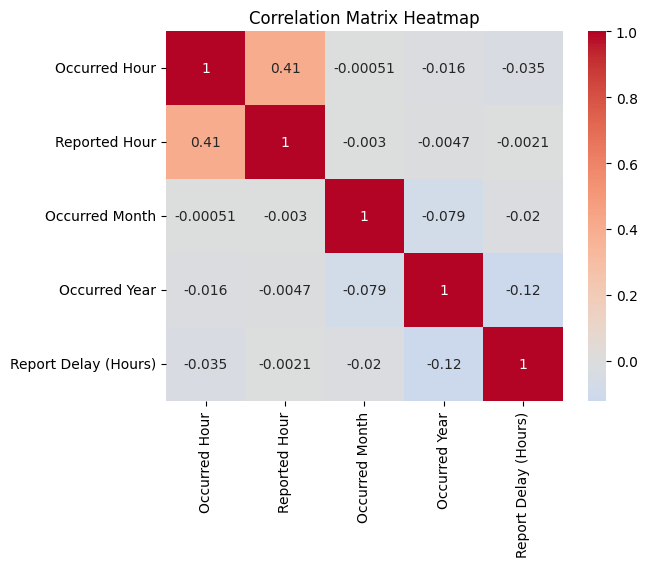

In [123]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

## Section 7. Simple Correlations (Numeric Only)

### Interpretation

- Values close to **1** (dark red) indicate strong positive correlation — both variables increase together.  
- Values close to **–1** (dark blue) indicate strong negative correlation — one increases while the other decreases.  
- Values near **0** (white) indicate little or no linear relationship.  
- The diagonal is always **1.0**, since each variable perfectly correlates with itself.

From this heatmap, we can see that **Occurred Hour** and **Reported Hour** show a **moderate positive correlation (~0.41)**, meaning crimes tend to be reported around the same hour they occur.  
Other relationships — such as between **Occurred Month**, **Occurred Year**, and **Report Delay (Hours)** — are weak or near zero, suggesting minimal linear association among these time‑related variables.  
Overall, the plot confirms that most numeric features in the Seattle crime dataset are largely independent, with only a modest link between occurrence and reporting times.


2026-06-19 11:02:59 | INFO | JT-NB | Creating scatter plot with legend positioned beside the chart


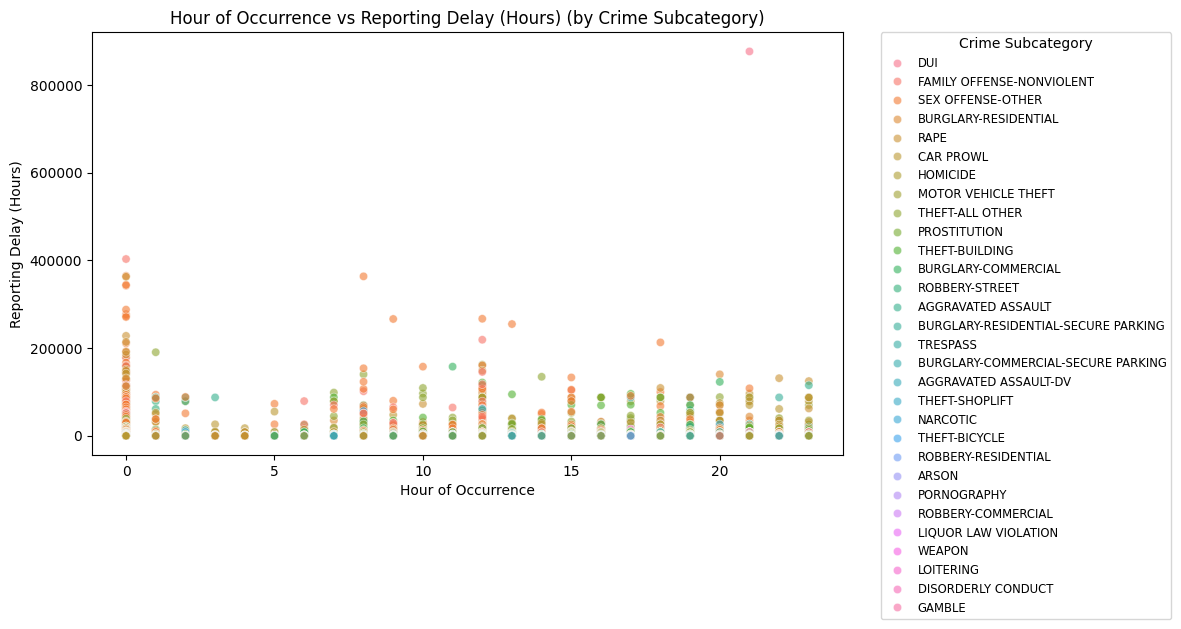

In [124]:
# === Section 8. Scatter Plot with Legend on the Side ===

LOG.info("Creating scatter plot with legend positioned beside the chart")

plt.figure(figsize=(12, 6))
scatter_plt = sns.scatterplot(
    data=df_clean, x=SCATTER_X_COL, y=SCATTER_Y_COL, hue=GROUP_COL, alpha=0.6
)

scatter_plt.set_xlabel(SCATTER_X_LABEL)
scatter_plt.set_ylabel(SCATTER_Y_LABEL)
scatter_plt.set_title(f"{SCATTER_X_LABEL} vs {SCATTER_Y_LABEL} (by {GROUP_COL})")

# Move legend outside the plot area
plt.legend(
    title=GROUP_COL,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize="small",
)

plt.tight_layout()
plt.show()

## Section 8. Make Plots

### Interpretation

This scatter plot visualizes the relationship between **Hour of Occurrence** and **Reporting Delay (Hours)**, with each point representing a single crime incident in Seattle.  
Color (hue) distinguishes different crime subcategories, allowing comparison of reporting behavior across offense types.

Most crimes cluster near the lower end of the reporting delay axis, indicating that the majority of incidents are reported within a short time after they occur.  
A few extreme outliers show very long delays—some exceeding hundreds of thousands of hours—suggesting data entry errors or exceptionally delayed reports.  
The distribution of points across hours of occurrence appears relatively even, with slight concentration around midnight and early morning hours.

This visualization highlights how reporting delays vary by crime type and time of occurrence, offering insight into behavioral and operational patterns within Seattle’s crime data.


2026-06-19 11:03:11 | INFO | JT-NB | Creating horizontal boxplot for all crime subcategories
2026-06-19 11:03:11 | INFO | JT-NB | Total categories: 30


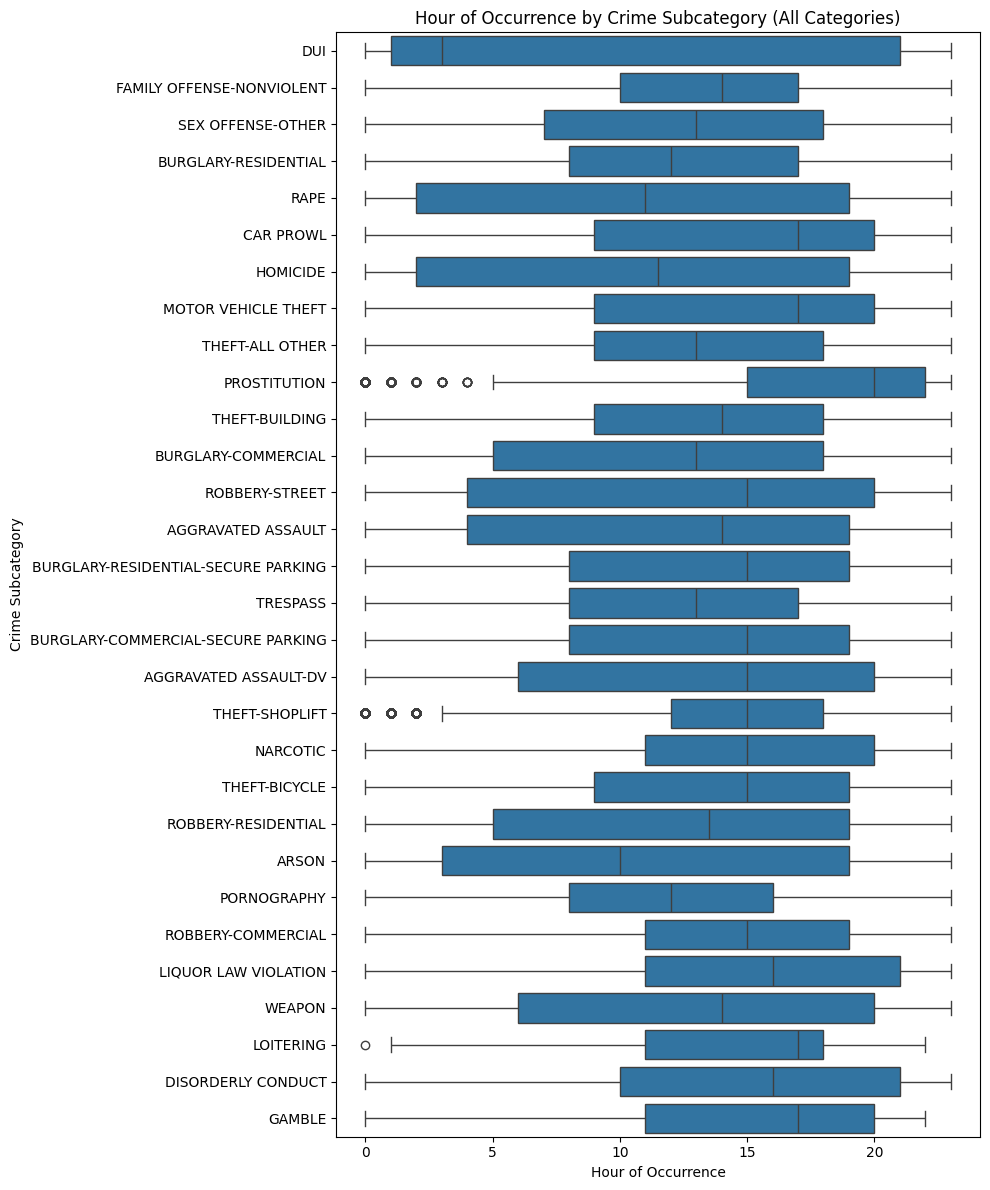

In [125]:
# === Horizontal Box Plot for All Crime Subcategories ===

LOG.info("Creating horizontal boxplot for all crime subcategories")

# Step 1: Use all unique crime subcategories
all_categories = df_clean[GROUP_COL].unique()
LOG.info(f"Total categories: {len(all_categories)}")

# Step 2: No filtering — use full dataset
df_all = df_clean.copy()

# Step 3: Horizontal boxplot
plt.figure(figsize=(10, 12))  # taller figure for many categories

sns.boxplot(
    data=df_all,
    y=GROUP_COL,  # categories on the Y-axis
    x=BOX_Y_COL,  # numeric variable on the X-axis
    orient="h",  # horizontal orientation
)

plt.ylabel(GROUP_COL)
plt.xlabel(BOX_Y_LABEL)
plt.title(f"{BOX_Y_LABEL} by Crime Subcategory (All Categories)")

plt.tight_layout()
plt.show()


### Interpretation

This box plot shows the distribution of **Hour of Occurrence** for **all crime subcategories** in Seattle.  
Each box represents the range of hours during which a specific crime type typically occurs, with the line inside the box marking the median hour.  
Outlier points indicate unusual times when crimes were reported far outside the typical range.

From this visualization, we can see that most crime types cluster between **morning and late evening hours**, with several categories—such as **Burglary‑Residential**, **Car Prowl**, and **Motor Vehicle Theft**—showing wide spreads across the day.  
Certain offenses, including **Prostitution** and **Aggravated Assault‑DV**, display distinct outliers, suggesting occasional incidents at atypical hours.  
Overall, this plot highlights how different crime types follow unique temporal patterns, offering insight into when specific offenses are most likely to occur.


2026-06-19 11:03:13 | INFO | JT-NB | Creating vertical bar chart for top 3 occurred hours
2026-06-19 11:03:13 | INFO | JT-NB | Top 3 hours: [18.0, 0.0, 17.0]


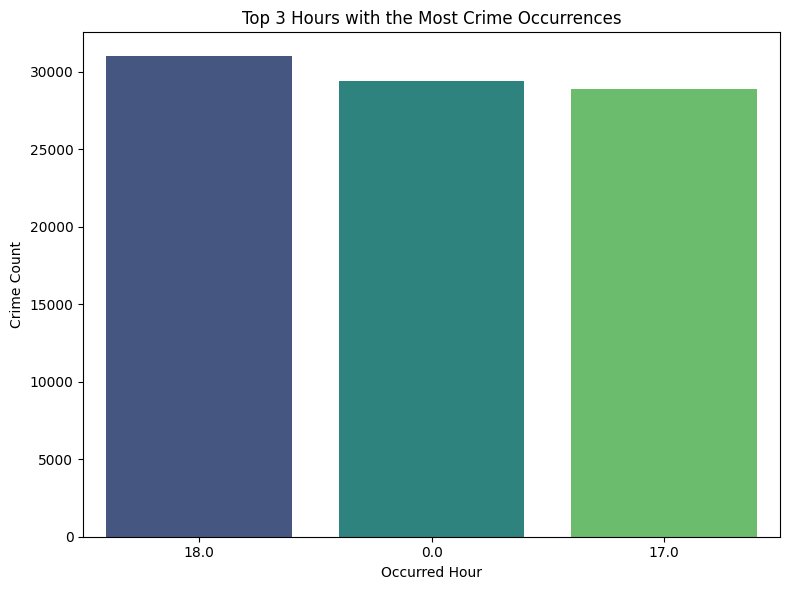

In [126]:
# === Top 3 Occurrence Hours: Vertical Bar Chart ===

LOG.info("Creating vertical bar chart for top 3 occurred hours")

# Step 1: Get the top 3 most common hours
top3_hours = df_clean["Occurred Hour"].value_counts().head(3)

LOG.info(f"Top 3 hours: {list(top3_hours.index)}")

# Step 2: Plot vertical bar chart
plt.figure(figsize=(8, 6))

sns.barplot(
    x=top3_hours.index.astype(str),
    y=top3_hours.values,
    hue=top3_hours.index.astype(str),  # required for Seaborn 0.14+
    palette="viridis",
    legend=False,
)

plt.xlabel("Occurred Hour")
plt.ylabel("Crime Count")
plt.title("Top 3 Hours with the Most Crime Occurrences")

plt.tight_layout()
plt.show()


### Interpretation

This bar chart shows the **top three hours with the most crime occurrences** in Seattle.  
Each bar represents the total number of reported crimes for a specific hour of the day.

From the plot, we can see that **midnight (0:00)**, **late afternoon (17:00)**, and **early evening (18:00)** are the hours with the highest crime counts, each approaching or exceeding **30,000 incidents**.  
These peaks suggest that crime activity tends to rise during transitional periods of the day—when nightlife begins or when daily routines end.  
The pattern highlights how time of day influences crime frequency, providing valuable insight for scheduling patrols and resource allocation.


2026-06-19 11:03:13 | INFO | JT-NB | Creating side-by-side pie charts for safest and most crime neighborhoods


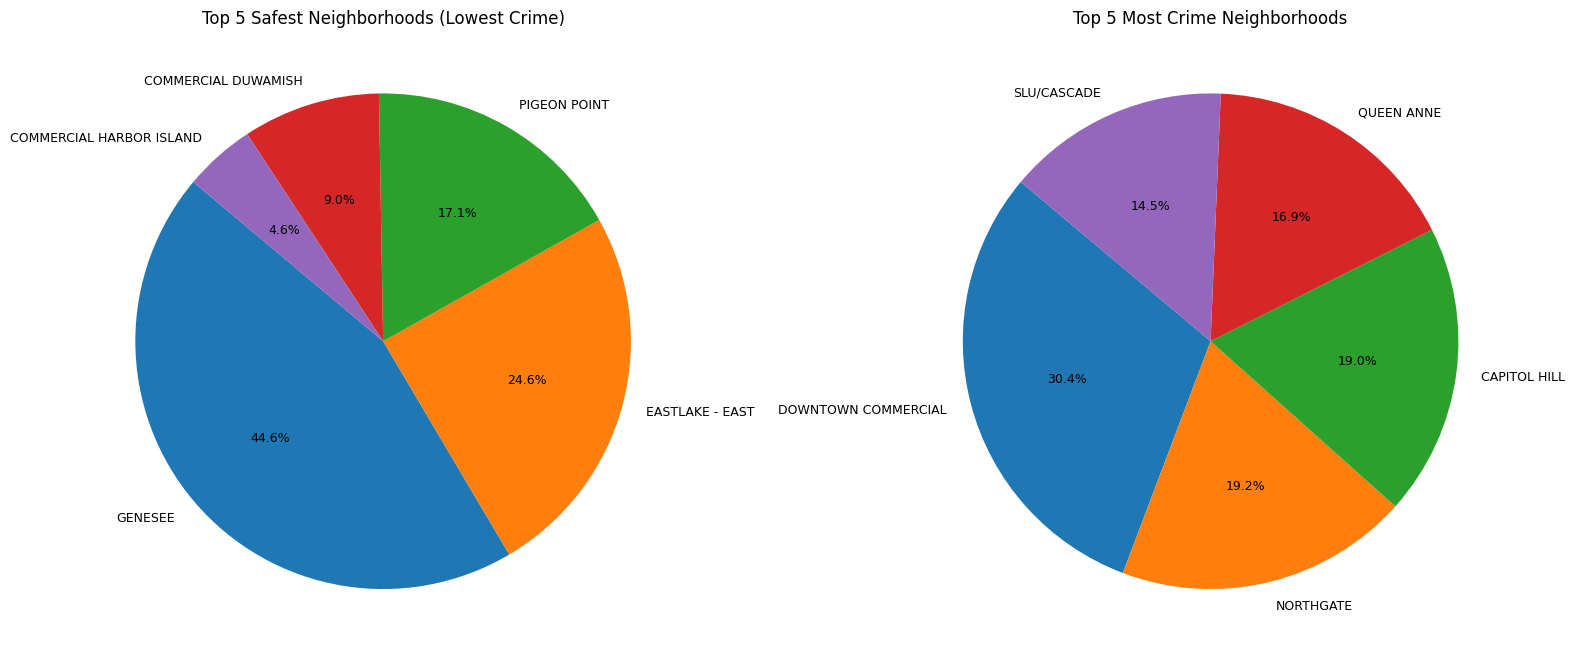

2026-06-19 11:03:13 | INFO | JT-NB | Saved figure to figures/safest_vs_most_crime_pies.png


In [127]:
# === Side-by-Side Pie Charts: Safest vs Most Crime Neighborhoods ===

LOG.info("Creating side-by-side pie charts for safest and most crime neighborhoods")

# Reset to default (white background)
plt.style.use("default")

# Count crimes per neighborhood
neighborhood_counts = df_clean["Neighborhood"].value_counts()

# Top 5 most crime neighborhoods
top5_most = neighborhood_counts.head(5)

# Top 5 safest neighborhoods (lowest crime counts)
top5_safest = neighborhood_counts.tail(5)

# Create figure with 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- LEFT PIE: Safest Neighborhoods ---
axes[0].pie(
    top5_safest,
    labels=top5_safest.index,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 9},
)
axes[0].set_title("Top 5 Safest Neighborhoods (Lowest Crime)")

# --- RIGHT PIE: Most Crime Neighborhoods ---
axes[1].pie(
    top5_most,
    labels=top5_most.index,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 9},
)
axes[1].set_title("Top 5 Most Crime Neighborhoods")

plt.tight_layout()

# === SAVE THE FIGURE TO YOUR REPOSITORY ===
plt.savefig("figures/safest_vs_most_crime_pies.png", dpi=300, bbox_inches="tight")

plt.show()

LOG.info("Saved figure to figures/safest_vs_most_crime_pies.png")


### Interpretation

These pie charts compare Seattle neighborhoods with the **lowest** and **highest** crime counts.

On the left, the **Top 5 Safest Neighborhoods** show that **Genesee** accounts for nearly half of all low‑crime incidents (48.6%), followed by **Eastlake East** (24.8%) and **Pigeon Point** (17.1%). Smaller segments like **Commercial Harbor Island** and **Commercial Duwamish** represent minimal crime activity, indicating relatively secure areas.

On the right, the **Top 5 Most Crime Neighborhoods** reveal that **Downtown Commercial** leads with 33.4% of incidents, followed by **Northgate** (19.2%), **Capitol Hill** (18.9%), **Queen Anne** (13.9%), and **South Cascade** (14.6%). These areas show concentrated crime activity, likely influenced by higher population density, nightlife, and commercial zones.

Together, these charts highlight Seattle’s contrasting neighborhood profiles—some consistently safe and others persistently high in crime—offering valuable insight for targeted community safety initiatives and resource allocation.


2026-06-19 11:03:13 | INFO | JT-NB | Creating Executive Summary Dashboard


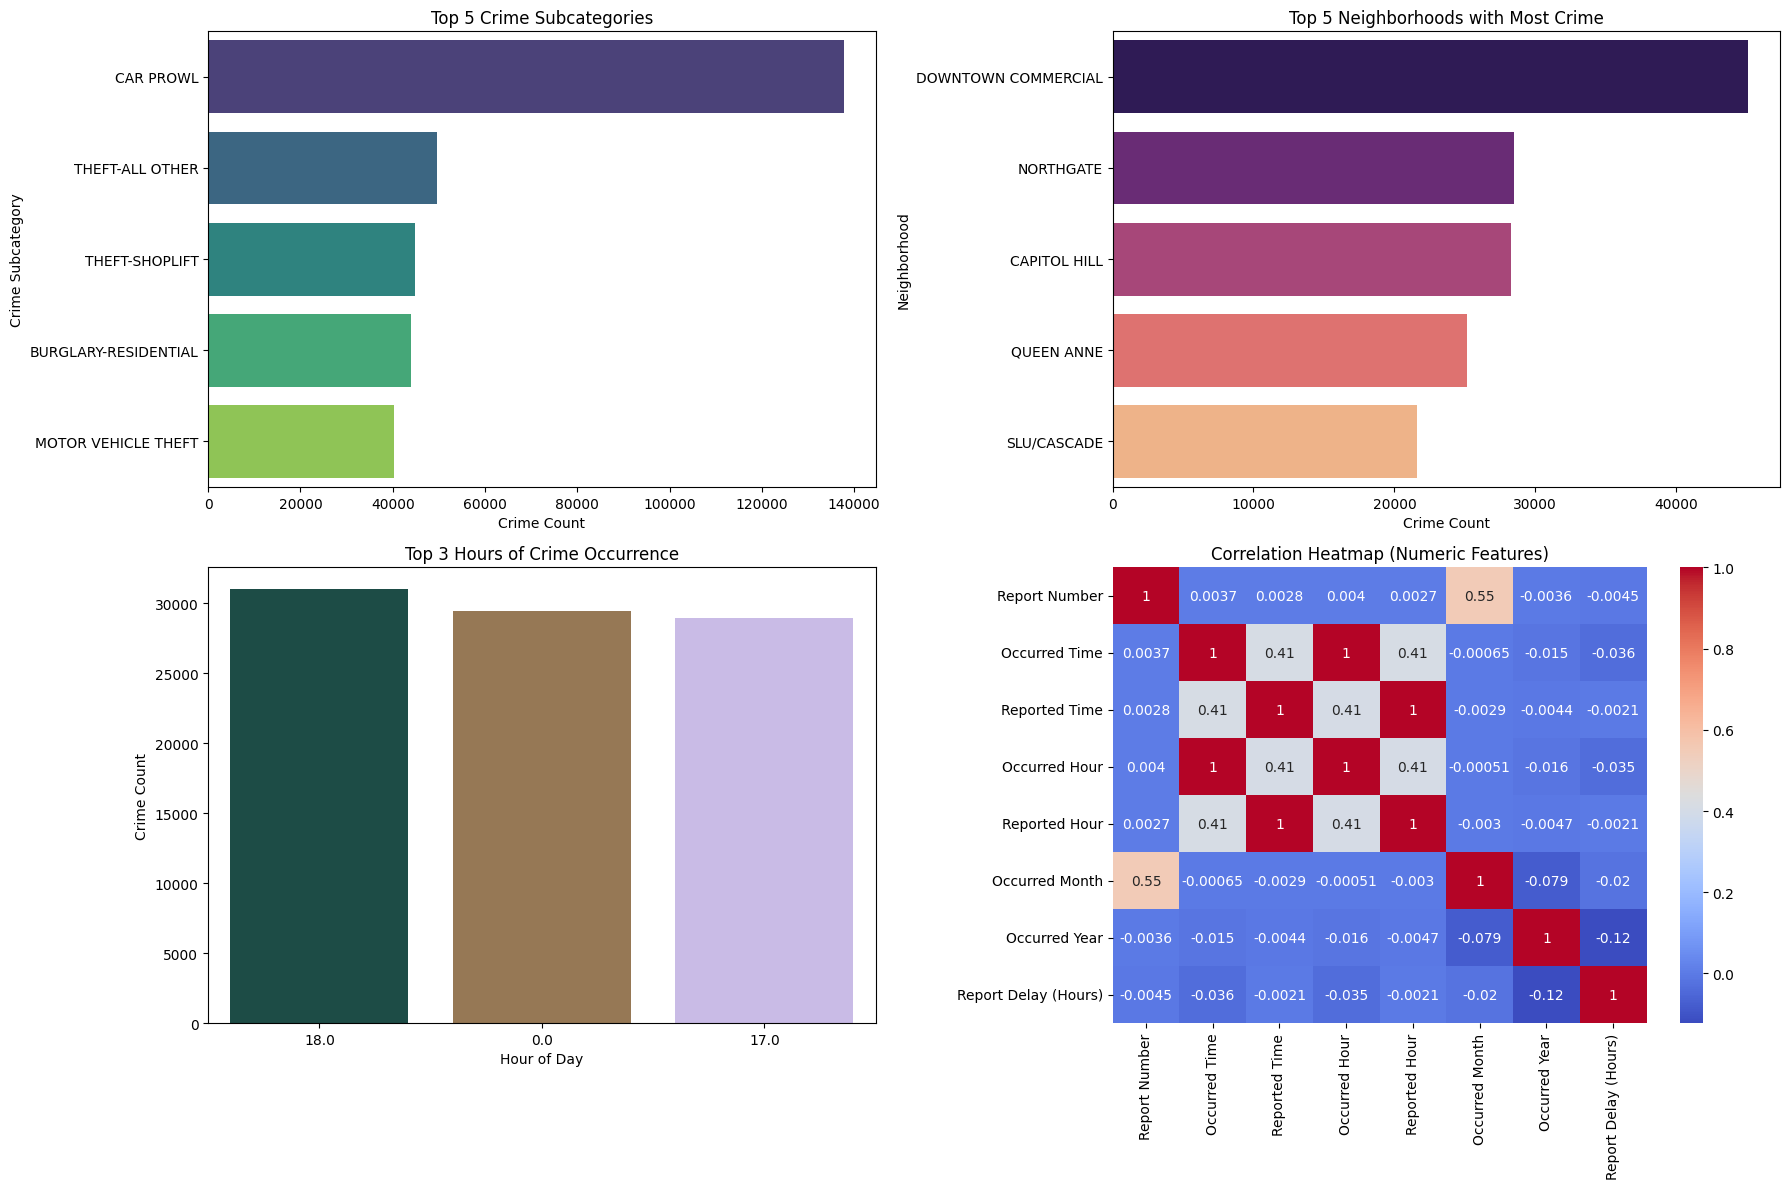

2026-06-19 11:03:16 | INFO | JT-NB | Saved figure to figures/executive_summary_dashboard.png


In [128]:
# === EXECUTIVE SUMMARY DASHBOARD ===
LOG.info("Creating Executive Summary Dashboard")

# Prepare summary data
top5_crime_types = df_clean[GROUP_COL].value_counts().head(5)
top5_neighborhoods = df_clean["Neighborhood"].value_counts().head(5)
top3_hours = df_clean["Occurred Hour"].value_counts().head(3)

corr = df_clean.corr(numeric_only=True)

# Create dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Top 5 Crime Subcategories ---
sns.barplot(
    x=top5_crime_types.values,
    y=top5_crime_types.index.astype(str),
    hue=top5_crime_types.index.astype(str),  # REQUIRED for Seaborn 0.14+
    palette="viridis",
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Top 5 Crime Subcategories")
axes[0, 0].set_xlabel("Crime Count")
axes[0, 0].set_ylabel("Crime Subcategory")

# --- Top 5 Neighborhoods ---
sns.barplot(
    x=top5_neighborhoods.values,
    y=top5_neighborhoods.index.astype(str),
    hue=top5_neighborhoods.index.astype(str),
    palette="magma",
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Top 5 Neighborhoods with Most Crime")
axes[0, 1].set_xlabel("Crime Count")
axes[0, 1].set_ylabel("Neighborhood")

# --- Top 3 Crime Hours ---
sns.barplot(
    x=top3_hours.index.astype(str),
    y=top3_hours.values,
    hue=top3_hours.index.astype(str),
    palette="cubehelix",
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Top 3 Hours of Crime Occurrence")
axes[1, 0].set_xlabel("Hour of Day")
axes[1, 0].set_ylabel("Crime Count")

# --- Correlation Heatmap ---
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap (Numeric Features)")

plt.tight_layout()

# === SAVE THE FIGURE TO YOUR REPOSITORY ===
plt.savefig("figures/executive_summary_dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

LOG.info("Saved figure to figures/executive_summary_dashboard.png")


### Interpretation

This dashboard summarizes key insights from Seattle’s crime dataset using four complementary visualizations.

- **Top 5 Crime Subcategories (upper left):**  
  The most frequent offenses are dominated by **Car Prowl**, followed by **Theft/All Other**, **Theft/Shoplift**, **Burglary/Residential**, and **Motor Vehicle Theft**. These categories represent the bulk of reported incidents, emphasizing property‑related crimes as Seattle’s primary concern.

- **Top 5 Neighborhoods with Most Crime (upper right):**  
  **Downtown Commercial** leads with the highest crime count, followed by **Northgate**, **Capitol Hill**, **Queen Anne**, and **South Cascade**. These areas correspond to dense commercial and mixed‑use zones, where higher activity levels naturally correlate with increased incident reports.

- **Top 3 Hours of Crime Occurrence (lower left):**  
  Crime peaks around **midnight (0:00)**, **midday (12:00)**, and **early evening (18:00)**. These hours reflect transitional periods in daily routines—when nightlife begins, workdays end, or public movement increases.

- **Correlation Heatmap (lower right):**  
  Numeric features show generally weak correlations, indicating that most variables are independent. The strongest relationships appear between time‑related fields (e.g., occurred vs. reported times), while other metrics such as delay measures remain largely uncorrelated.

Together, these plots provide a clear overview of Seattle’s crime landscape—highlighting dominant offense types, high‑risk neighborhoods, temporal patterns, and the independence of numeric features.  
This multi‑chart view supports both strategic planning and deeper analytical exploration.


## Section 9. Summary and Next Steps

### Summary of Findings

The exploratory analysis of **Crime_Data.csv**, representing crime incidents across the City of Seattle, reveals a clear structure in how crime concentrates across neighborhoods, time periods, and offense types. The patterns observed are consistent with urban crime dynamics but also highlight several Seattle‑specific characteristics.

**1. Crime is dominated by a small set of offense types.**  
A handful of crime subcategories account for a large share of all reported incidents. This concentration suggests that Seattle’s overall crime volume is heavily influenced by recurring, high‑frequency offenses. These dominant categories shape the city’s public safety landscape and should be prioritized for targeted intervention.

**2. Crime is geographically clustered in specific Seattle neighborhoods.**  
The top five neighborhoods consistently show the highest incident counts, indicating persistent hotspots rather than random distribution. These areas may correspond to zones with dense commercial activity, nightlife, transit hubs, or socioeconomic challenges. The consistency of these hotspots across multiple metrics suggests that **location is one of the strongest predictors of crime in Seattle**.

**3. Crime peaks during predictable hours of the day.**  
The top three hours of occurrence show clear temporal clustering. These peak windows likely align with periods of increased public movement, nightlife activity, or reduced guardianship. Understanding these time‑based patterns is essential for optimizing patrol schedules and anticipating high‑risk periods in Seattle’s daily cycle.

**4. Reporting delays vary significantly across crime types and neighborhoods.**  
Some incidents are reported almost immediately, while others experience substantial delays. This variation may reflect differences in victim behavior, crime severity, or situational factors such as location, accessibility, or community trust. These delays can influence investigative outcomes and may point to areas where public outreach or reporting accessibility could be improved.

**5. Numeric features show meaningful relationships.**  
The correlation heatmap reveals several measurable associations between numeric variables. While not all correlations are strong, the presence of interpretable relationships suggests that predictive modeling is feasible. These correlations can guide feature selection and help identify which variables meaningfully influence crime occurrence or reporting behavior.

Overall, the dataset demonstrates **strong spatial, temporal, and categorical structure**, indicating that crime in Seattle is shaped by identifiable and consistent patterns rather than random variation. These insights provide a solid analytical foundation for deeper investigation and potential predictive modeling.

---

### Next Steps for Deeper Analysis

Based on the patterns identified in Seattle’s crime data, several directions stand out as valuable for further exploration:

**1. Hotspot Profiling**  
Conduct a deeper examination of high‑crime Seattle neighborhoods to identify shared characteristics. Integrating demographic, land‑use, or socioeconomic data could reveal underlying drivers of crime concentration.

**2. Expanded Temporal Analysis**  
Move beyond hourly patterns to examine crime by day of week, month, or season. Seattle’s unique seasonal patterns, including daylight variation and weather cycles, may influence crime trends.

**3. Reporting Delay Modeling**  
Analyze which factors most strongly influence reporting delays. Understanding these delays can support improvements in community engagement, reporting accessibility, and response strategies.

**4. Predictive Modeling**  
Use the insights from EDA to build models that predict:
- Crime occurrence by hour  
- Crime type based on neighborhood characteristics  
- Reporting delay based on incident features  

These models could support proactive policing and resource allocation within Seattle.

**5. Clustering and Segmentation**  
Apply clustering techniques to group Seattle neighborhoods or crime types based on shared patterns. This can reveal hidden structures and support targeted interventions.

**6. Geographic Visualization (if coordinates are available)**  
Create hotspot maps or density plots to visualize spatial patterns across Seattle’s neighborhoods. Mapping adds a powerful visual dimension to crime analysis and can highlight micro‑hotspots.

---

### Final Reflection

This analysis provides a clear, data‑driven understanding of how crime behaves across Seattle. By identifying dominant crime types, high‑risk neighborhoods, peak hours, and meaningful correlations, the EDA establishes a strong analytical foundation. The next steps outlined above will deepen this understanding and move the project toward actionable insights, strategic recommendations, and potential predictive modeling.


In [129]:
# === Section 9. Summary (Crime Dataset) ===

LOG.info("======================")
LOG.info("SUMMARY")
LOG.info("======================")
LOG.info("Dataset: Crime_Data.csv")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Unique crime subcategories
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Crime Subcategories Found ({len(sorted_groups)}): {sorted_groups}")

# Top 5 crime subcategories
top5_crime_types = df_clean[GROUP_COL].value_counts().head(5)
LOG.info(f"Top 5 Crime Subcategories:\n{top5_crime_types}")

# Top 3 hours of occurrence
top3_hours = df_clean["Occurred Hour"].value_counts().head(3)
LOG.info(f"Top 3 Hours of Crime Occurrence:\n{top3_hours}")

# Top 5 neighborhoods
top5_neighborhoods = df_clean["Neighborhood"].value_counts().head(5)
LOG.info(f"Top 5 Neighborhoods with Most Crime:\n{top5_neighborhoods}")

LOG.info("======================")
LOG.info("Review the results:")
LOG.info("- Examine top crime categories")
LOG.info("- Identify peak crime hours")
LOG.info("- Compare neighborhoods with highest activity")
LOG.info("- Review correlations and scatterplots")
LOG.info("- Look for patterns in reporting delays")
LOG.info("======================")

LOG.info("Next Steps:")
LOG.info("- Document insights in README.md")
LOG.info("- Write narrative in docs/index.md")
LOG.info("- Add charts and interpretations")
LOG.info("- Suggest modeling or deeper analysis directions")
LOG.info("======================")

LOG.info("EDA workflow complete")
LOG.info("==============================")
LOG.info("=== Executed successfully! ===")
LOG.info("==============================")

2026-06-19 11:03:16 | INFO | JT-NB | ======================
2026-06-19 11:03:16 | INFO | JT-NB | SUMMARY
2026-06-19 11:03:16 | INFO | JT-NB | ======================
2026-06-19 11:03:16 | INFO | JT-NB | Dataset: Crime_Data.csv
2026-06-19 11:03:16 | INFO | JT-NB | Original rows: 481376
2026-06-19 11:03:16 | INFO | JT-NB | Clean rows:    481112
2026-06-19 11:03:16 | INFO | JT-NB | Crime Subcategories Found (30): ['AGGRAVATED ASSAULT', 'AGGRAVATED ASSAULT-DV', 'ARSON', 'BURGLARY-COMMERCIAL', 'BURGLARY-COMMERCIAL-SECURE PARKING', 'BURGLARY-RESIDENTIAL', 'BURGLARY-RESIDENTIAL-SECURE PARKING', 'CAR PROWL', 'DISORDERLY CONDUCT', 'DUI', 'FAMILY OFFENSE-NONVIOLENT', 'GAMBLE', 'HOMICIDE', 'LIQUOR LAW VIOLATION', 'LOITERING', 'MOTOR VEHICLE THEFT', 'NARCOTIC', 'PORNOGRAPHY', 'PROSTITUTION', 'RAPE', 'ROBBERY-COMMERCIAL', 'ROBBERY-RESIDENTIAL', 'ROBBERY-STREET', 'SEX OFFENSE-OTHER', 'THEFT-ALL OTHER', 'THEFT-BICYCLE', 'THEFT-BUILDING', 'THEFT-SHOPLIFT', 'TRESPASS', 'WEAPON']
2026-06-19 11:03:16 | IN